[report](https://https://docs.google.com/document/d/1WvQ2j0TfRAjTFcPs7Wke8g6hrgZ-NuxKndkoa2wUqu8/edit?usp=sharing)

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
dataset= pd.read_csv("/content/drive/MyDrive/project422/2.csv")

# **EDA**


In [ ]:
dataset

,Lines_of_Code,Cyclomatic_Complexity,Num_Functions,Code_Churn,Comment_Density,Num_Bugs,Has_Unit_Tests,Code_Owner_Experience,Quality_Label
0,356.0,31,144,69.567047,0.467561,2,Yes,4,Medium
1,227.0,15,104,131.844422,0.795643,2,No,5,High
2,9674.0,47,141,118.729027,0.316839,5,No,1,High
3,6967.0,42,107,194.397155,0.971883,5,Yes,3,Low
4,7954.0,35,114,69.202293,0.559417,1,No,8,Medium
...,...,...,...,...,...,...,...,...,...
1595,8883.0,40,31,54.863010,0.928920,3,Yes,8,Low
1596,2175.0,44,25,160.802073,0.696037,3,No,1,Low
1597,7872.0,39,47,121.382316,0.461773,3,No,2,High
1598,9660.0,24,55,75.626324,0.999547,2,No,6,Low


In [ ]:
print ('Shape of the dataset is {}. This dataset contains {} rows and {} columns.'.format(dataset.shape,dataset.shape[0],dataset.shape[1]))

Shape of the dataset is (1600, 9). This dataset contains 1600 rows and 9 columns.


In [ ]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1600 entries, 0 to 1599
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Lines_of_Code          1520 non-null   float64
 1   Cyclomatic_Complexity  1600 non-null   int64  
 2   Num_Functions          1600 non-null   int64  
 3   Code_Churn             1520 non-null   float64
 4   Comment_Density        1520 non-null   float64
 5   Num_Bugs               1600 non-null   int64  
 6   Has_Unit_Tests         1600 non-null   object 
 7   Code_Owner_Experience  1600 non-null   int64  
 8   Quality_Label          1600 non-null   object 
dtypes: float64(3), int64(4), object(2)
memory usage: 112.6+ KB


In [ ]:
numerical_data = dataset.select_dtypes(include='number')

#append the features of numerical_data to list
numerical_features=numerical_data.columns.tolist()

print(f'There are {len(numerical_features)} numerical features:', '\n')
print(numerical_features)

There are 7 numerical features: 

['Lines_of_Code', 'Cyclomatic_Complexity', 'Num_Functions', 'Code_Churn', 'Comment_Density', 'Num_Bugs', 'Code_Owner_Experience']


In [ ]:
categorical_data=dataset.select_dtypes(include= 'object')

#append the features of categorical_data to list
categorical_features=categorical_data.columns.tolist()

print(f'There are {len(categorical_features)} categorical features:', '\n')
print(categorical_features)

There are 2 categorical features: 

['Has_Unit_Tests', 'Quality_Label']


In [ ]:
numerical_data.describe().T

,count,mean,std,min,25%,50%,75%,max
Lines_of_Code,1520.0,4939.269737,2867.248259,106.000000,2490.750000,4860.000000,7455.250000,9998.000000
Cyclomatic_Complexity,1600.0,25.076875,13.879621,1.000000,13.000000,25.000000,37.000000,49.000000
Num_Functions,1600.0,103.178125,55.503710,5.000000,56.000000,104.000000,152.000000,199.000000
Code_Churn,1520.0,102.572291,50.546329,-64.283310,67.509852,104.007452,138.619113,295.139936
Comment_Density,1520.0,0.549370,0.256137,0.101037,0.337596,0.542108,0.765766,0.999976
Num_Bugs,1600.0,2.934375,1.715928,0.000000,2.000000,3.000000,4.000000,10.000000
Code_Owner_Experience,1600.0,5.045000,2.559701,1.000000,3.000000,5.000000,7.000000,9.000000


In [ ]:
categorical_data.describe().T

,count,unique,top,freq
Has_Unit_Tests,1600,2,No,820
Quality_Label,1600,3,High,566


In [ ]:
numerical_data.var()

,0
Lines_of_Code,8.221113e+06
Cyclomatic_Complexity,1.926439e+02
Num_Functions,3.080662e+03
Code_Churn,2.554931e+03
Comment_Density,6.560604e-02
Num_Bugs,2.944409e+00
Code_Owner_Experience,6.552070e+00


In [ ]:
numerical_data.skew()

,0
Lines_of_Code,0.055175
Cyclomatic_Complexity,0.015461
Num_Functions,-0.034194
Code_Churn,-0.113186
Comment_Density,0.004302
Num_Bugs,0.667812
Code_Owner_Experience,-0.042283


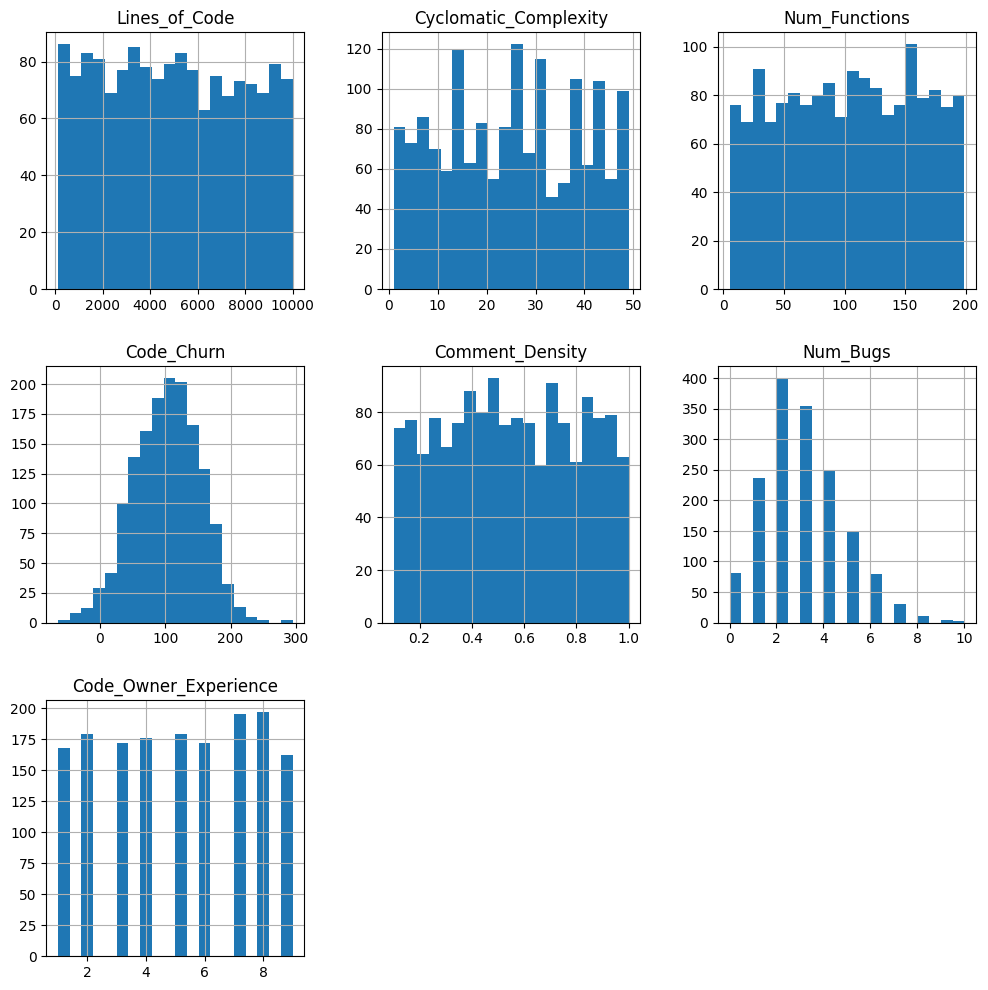

In [ ]:
numerical_data.hist(figsize=(12,12),bins=20)
plt.show()

In [ ]:
numerical_data.nunique()

,0
Lines_of_Code,1413
Cyclomatic_Complexity,49
Num_Functions,195
Code_Churn,1520
Comment_Density,1520
Num_Bugs,11
Code_Owner_Experience,9


In [ ]:
numerical_data.isnull().sum()

,0
Lines_of_Code,80
Cyclomatic_Complexity,0
Num_Functions,0
Code_Churn,80
Comment_Density,80
Num_Bugs,0
Code_Owner_Experience,0


In [ ]:
unique_counts=categorical_data.nunique()
print(unique_counts)

Has_Unit_Tests    2
Quality_Label     3
dtype: int64


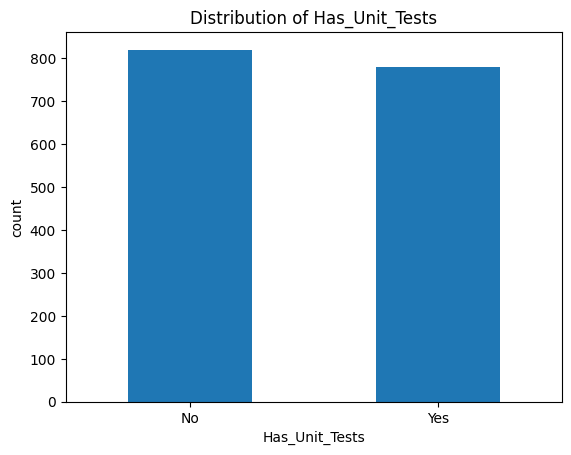

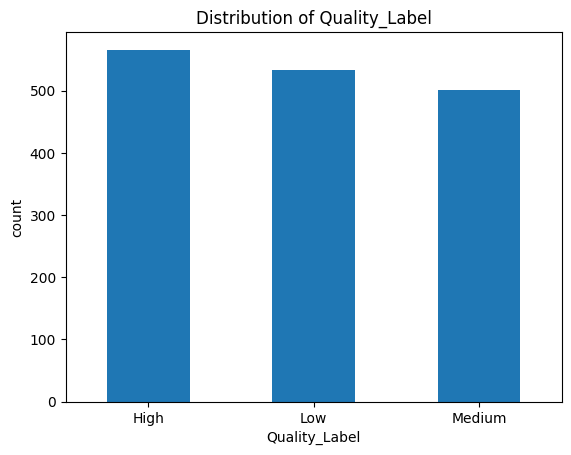

In [ ]:
for col in categorical_features:
    plt.title(f'Distribution of {col}')
    categorical_data[col].value_counts().sort_index().plot(kind='bar', rot=0, xlabel=col,ylabel='count')
    plt.show()

In [ ]:
correlation_matrix = numerical_data.corr()
correlation_matrix

,Lines_of_Code,Cyclomatic_Complexity,Num_Functions,Code_Churn,Comment_Density,Num_Bugs,Code_Owner_Experience
Lines_of_Code,1.000000,0.046746,-0.026398,0.003710,0.019014,-0.029780,0.015243
Cyclomatic_Complexity,0.046746,1.000000,-0.005937,-0.022347,0.041138,-0.076648,-0.019038
Num_Functions,-0.026398,-0.005937,1.000000,-0.005121,-0.002924,0.007963,0.011028
Code_Churn,0.003710,-0.022347,-0.005121,1.000000,0.010962,-0.015592,0.022090
Comment_Density,0.019014,0.041138,-0.002924,0.010962,1.000000,-0.045190,0.028216
Num_Bugs,-0.029780,-0.076648,0.007963,-0.015592,-0.045190,1.000000,-0.008013
Code_Owner_Experience,0.015243,-0.019038,0.011028,0.022090,0.028216,-0.008013,1.000000


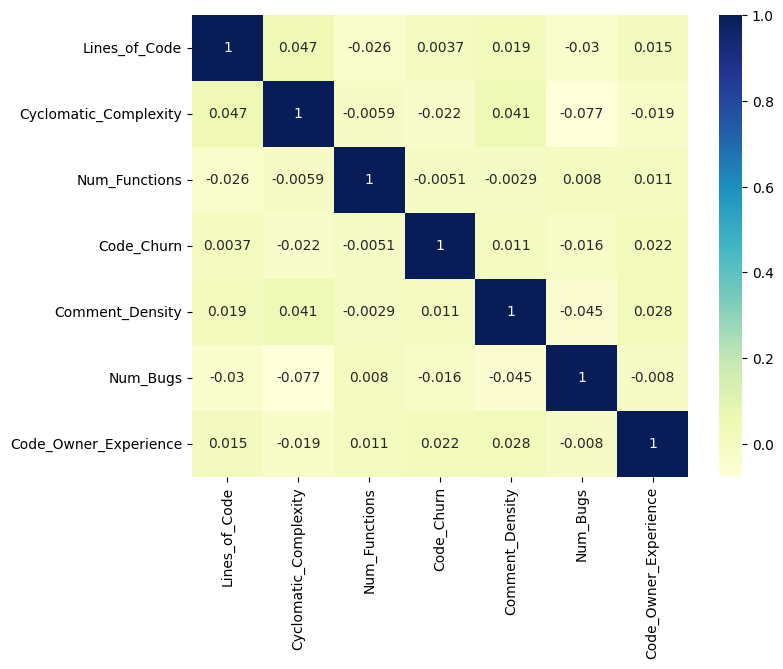

In [ ]:
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='YlGnBu')
plt.show()

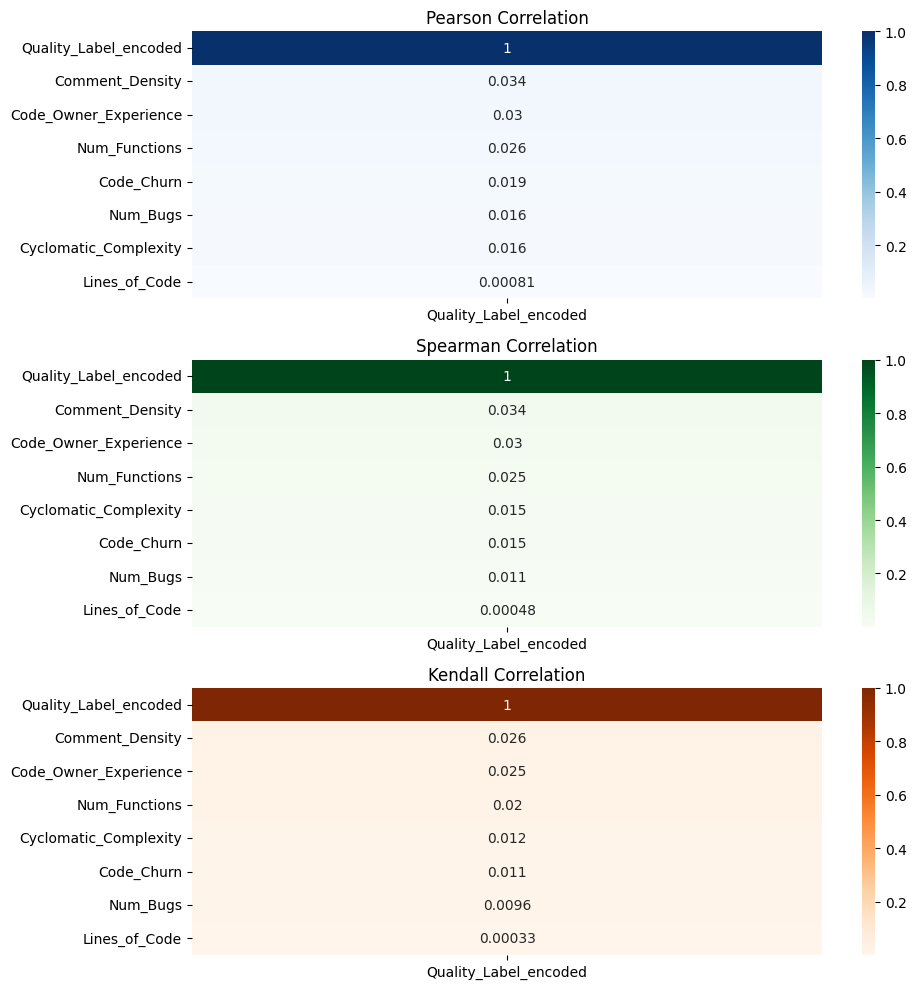

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Step 1: Create EDA dataframe

eda_data = dataset.copy()   # df = your original dataset

# Temporary encoding of target (EDA only)
eda_data['Quality_Label_encoded'] = (
    eda_data['Quality_Label'].astype('category').cat.codes
)

# Select only numeric columns for correlation
eda_numeric = eda_data.select_dtypes(include='number')

# Step 2: Create plots

fig, ax = plt.subplots(3, 1, figsize=(10, 10))

corr_pearson = eda_numeric.corr(method='pearson')[['Quality_Label_encoded']] \
                    .sort_values(by='Quality_Label_encoded', ascending=False)

corr_spearman = eda_numeric.corr(method='spearman')[['Quality_Label_encoded']] \
                    .sort_values(by='Quality_Label_encoded', ascending=False)

corr_kendall = eda_numeric.corr(method='kendall')[['Quality_Label_encoded']] \
                    .sort_values(by='Quality_Label_encoded', ascending=False)

ax[0].set_title('Pearson Correlation')
ax[1].set_title('Spearman Correlation')
ax[2].set_title('Kendall Correlation')

sns.heatmap(corr_pearson, ax=ax[0], annot=True, cmap="Blues")
sns.heatmap(corr_spearman, ax=ax[1], annot=True, cmap="Greens")
sns.heatmap(corr_kendall, ax=ax[2], annot=True, cmap="Oranges")

plt.tight_layout()
plt.show()

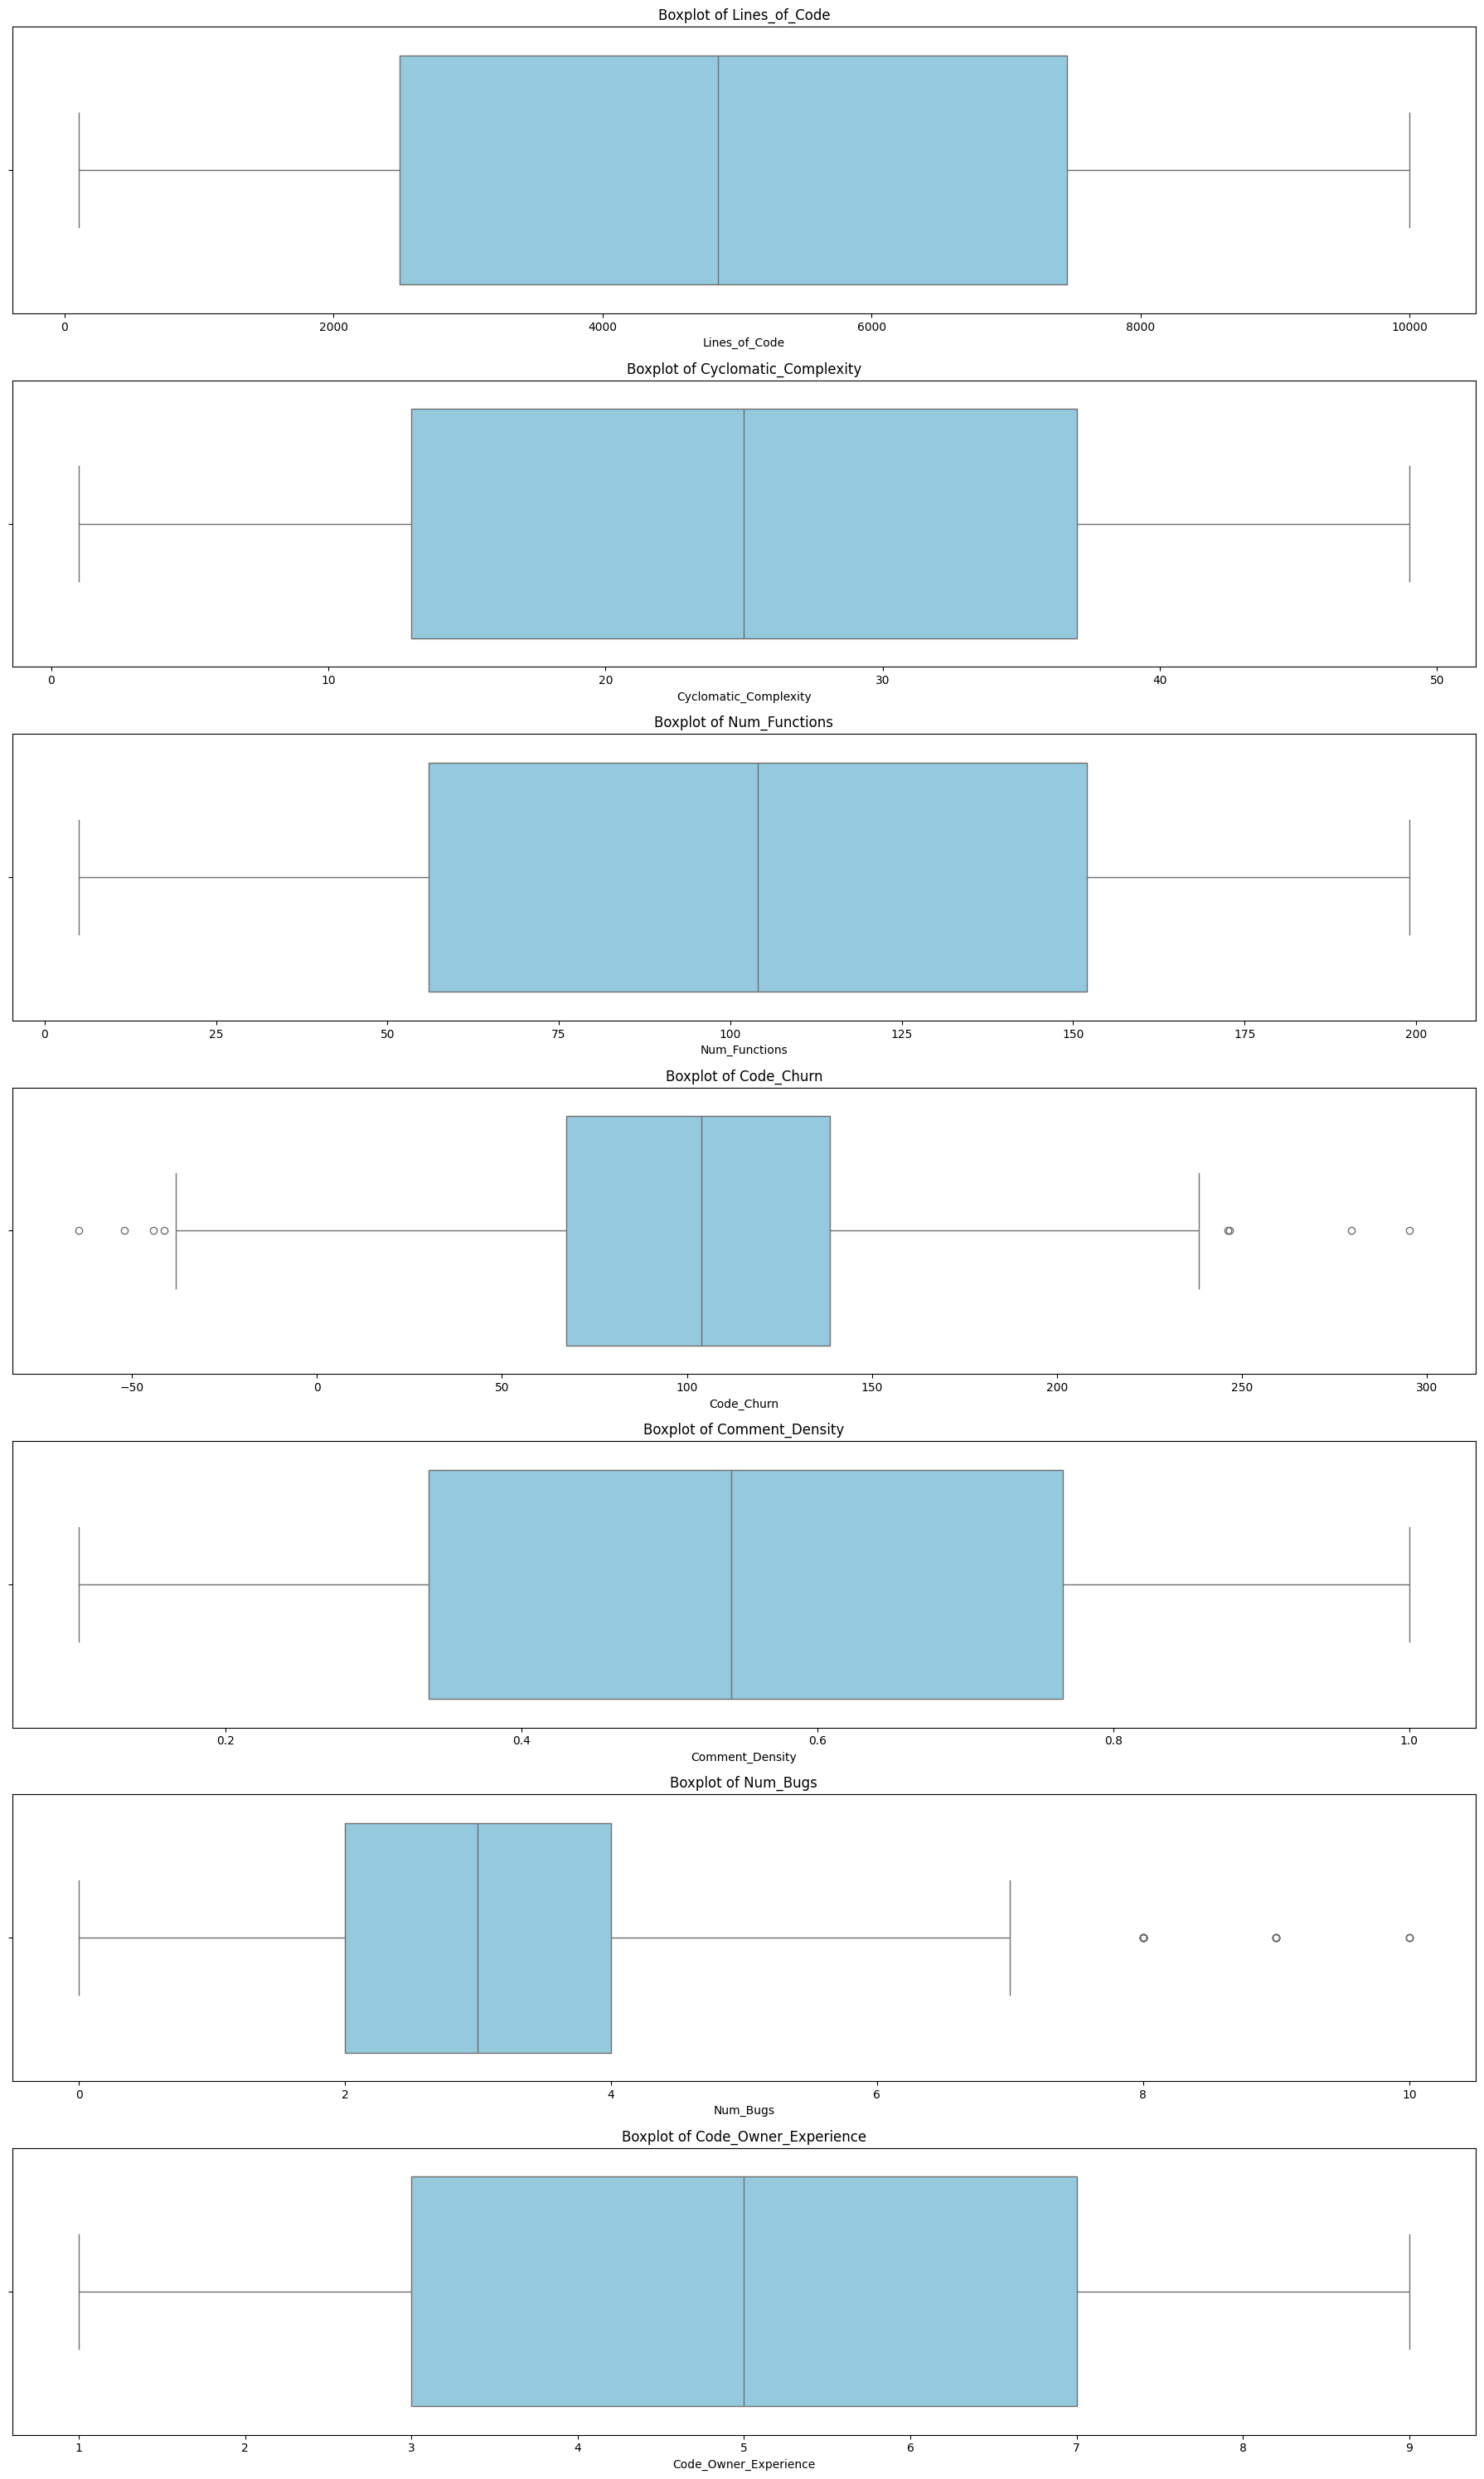

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Define categorical columns

categorical_cols = ['Quality_Label', 'Has_Unit_Tests']

# Select numerical columns only
numeric_cols = [col for col in dataset.columns if col not in categorical_cols]


# Set up the figure

plt.figure(figsize=(18, 30))

# Plot boxplots for each numerical feature
for i, col in enumerate(numeric_cols, 1):
    plt.subplot(len(numeric_cols), 1, i)
    sns.boxplot(x=dataset[col], color='skyblue')
    plt.title(f'Boxplot of {col}', fontsize=12)
    plt.tight_layout()

plt.show()

In [ ]:
import pandas as pd

# Group instances based on classes in Quality_Label
class_counts = dataset['Quality_Label'].value_counts()

# Prepare lists for DataFrame
outcome = class_counts.index.tolist()
count = class_counts.values.tolist()
percentage = [(c / len(dataset)) * 100 for c in count]

# Create a DataFrame showing counts and percentages
imbalance_df = pd.DataFrame({
    'Outcome': outcome,
    'Count': count,
    'Percentage': percentage
})

# Display the imbalance table
imbalance_df


,Outcome,Count,Percentage
0,High,566,35.3750
1,Low,533,33.3125
2,Medium,501,31.3125


/tmp/ipython-input-1415340667.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


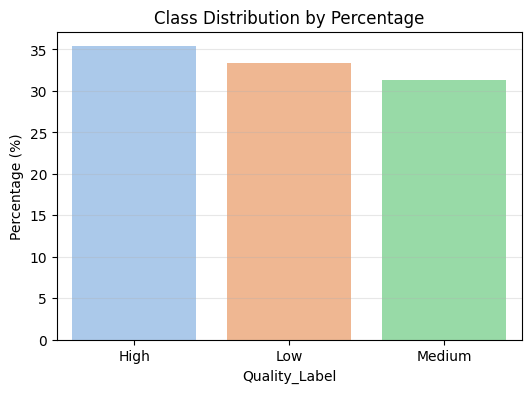

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set figure size
plt.figure(figsize=(6, 4))

# Create barplot of Outcome vs Percentage
sns.barplot(
    data=imbalance_df,
    x='Outcome',           # column name in imbalance_df
    y='Percentage',        # column name in imbalance_df
    palette='pastel'
)


plt.title('Class Distribution by Percentage')
plt.xlabel('Quality_Label')
plt.ylabel('Percentage (%)')

plt.grid(axis='y', alpha=0.3)
plt.show()


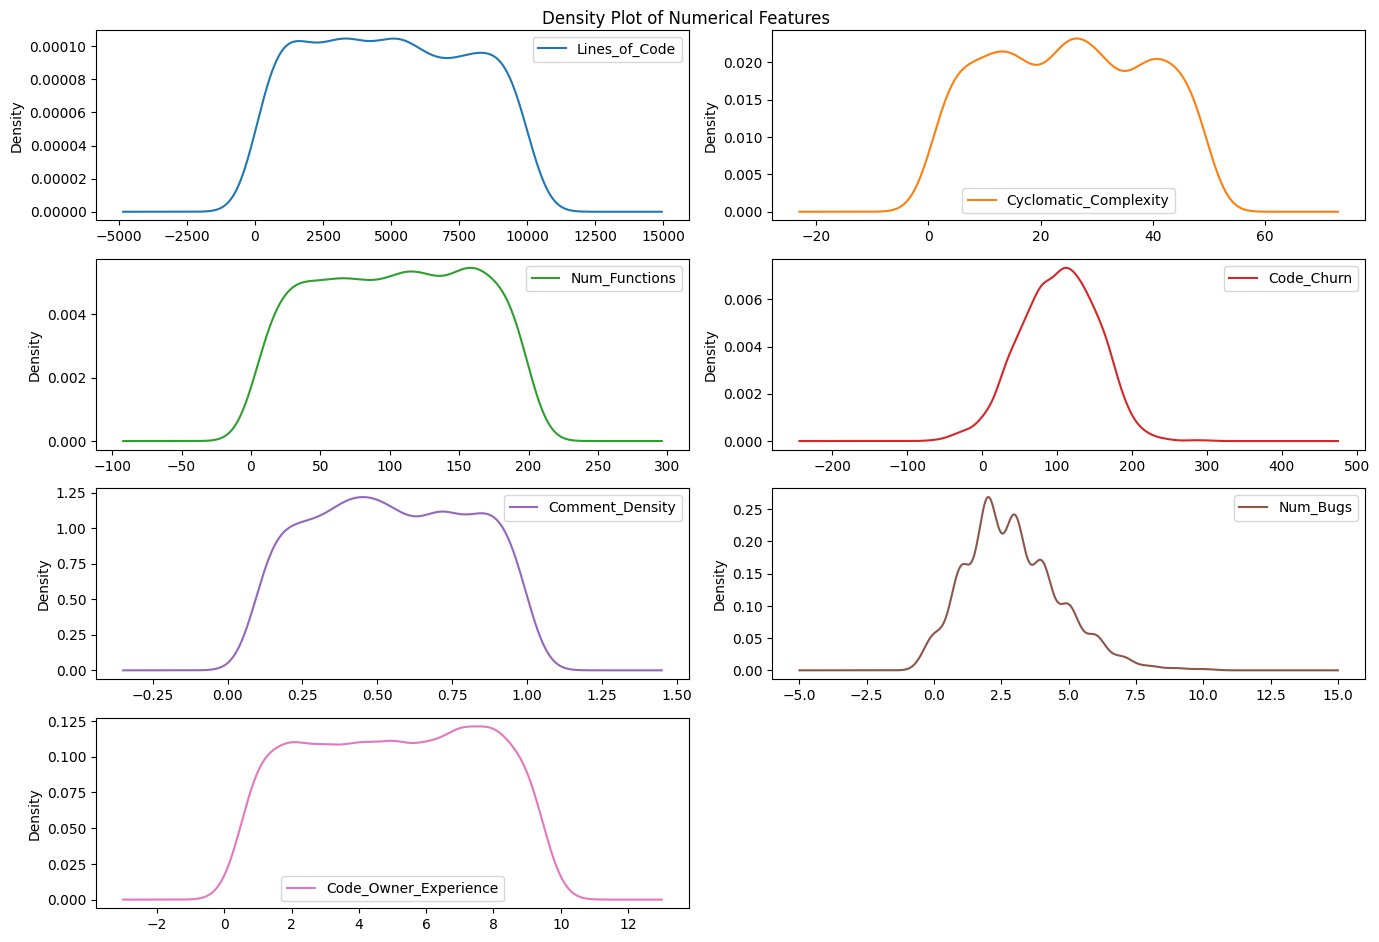

In [ ]:
# density plot

import matplotlib.pyplot as plt

# Define categorical columns
categorical_cols = ['Quality_Label', 'Has_Unit_Tests']

# Select only numerical columns
numerical_data = dataset.drop(columns=categorical_cols)

# Plot density plots for all numerical features
numerical_data.plot(
    kind='density',
    figsize=(14, 14),
    subplots=True,
    layout=(6, 2),        # adjust layout based on number of features
    title="Density Plot of Numerical Features",
    sharex=False
)

plt.tight_layout()
plt.show()


# **DATA SPLITTING**

In [ ]:
dataset['Has_Unit_Tests'].unique()

array(['Yes', 'No'], dtype=object)

In [ ]:
dataset['Quality_Label'].unique()

array(['Medium', 'High', 'Low'], dtype=object)

**Feature Engineering: Categorical Encoding**

**Option 1: Data With heirarchy Data with heirarchy / ranking - map()**



In [ ]:
# hiking['Accessible'] = hiking['Accessible'].map({'good':2,'bad':0,'average':1})

dataset['Has_Unit_Tests'] = dataset['Has_Unit_Tests'].map({'Yes':1,'No':0})
dataset['Quality_Label'] = dataset['Quality_Label'].map({'High':2,'Low':0,'Medium':1})

dataset['Quality_Label'].info()

<class 'pandas.core.series.Series'>
RangeIndex: 1600 entries, 0 to 1599
Series name: Quality_Label
Non-Null Count  Dtype
--------------  -----
1600 non-null   int64
dtypes: int64(1)
memory usage: 12.6 KB


In [ ]:
dataset['Has_Unit_Tests'].unique()

array([1, 0])

In [ ]:
dataset['Quality_Label'].unique()

array([1, 2, 0])

**splitting**

In [ ]:
from sklearn.model_selection import train_test_split

# Columns: Lines_of_Code, Cyclomatic_Complexity, Num_Functions, Code_Churn,
# Comment_Density, Num_Bugs, Has_Unit_Tests, Code_Owner_Experience, Quality_Label

# X = dataset
X = dataset.drop("Quality_Label", axis=1)
y = dataset["Quality_Label"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, stratify=y, random_state=42)


In [ ]:
print("X_train_shape:", X_train.shape)
print("y_train_shape:", y_train.shape)

print("X_train_shape:", X_test.shape)
print("y_train_shape:", y_test.shape)

X_train_shape: (1120, 8)
y_train_shape: (1120,)
X_train_shape: (480, 8)
y_train_shape: (480,)


In [ ]:
dataset['Quality_Label']

,Quality_Label
0,1
1,2
2,2
3,0
4,1
...,...
1595,0
1596,0
1597,2
1598,0


In [ ]:
# scatter matrix

In [ ]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1600 entries, 0 to 1599
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Lines_of_Code          1520 non-null   float64
 1   Cyclomatic_Complexity  1600 non-null   int64  
 2   Num_Functions          1600 non-null   int64  
 3   Code_Churn             1520 non-null   float64
 4   Comment_Density        1520 non-null   float64
 5   Num_Bugs               1600 non-null   int64  
 6   Has_Unit_Tests         1600 non-null   int64  
 7   Code_Owner_Experience  1600 non-null   int64  
 8   Quality_Label          1600 non-null   int64  
dtypes: float64(3), int64(6)
memory usage: 112.6 KB


# **DATA PRE PROCESSING**

**Handling null values. Option 02: Dropping rows with null values**





In [ ]:
#sales[['salt']]
# dataset[['Lines_of_Code', 'Code_Churn', 'Comment_Density']]

In [ ]:
# dataset.head(25)

In [ ]:
# dataset= pd.read_csv("/content/drive/MyDrive/project422/2.csv")

In [ ]:
# print("Missing values per column:\n", dataset.isnull().sum())

print("Shape before dropping rows with missing values:", dataset.shape)

dataset = dataset.dropna(axis=0, subset=['Lines_of_Code', 'Code_Churn', 'Comment_Density'])

print("Shape after dropping rows with missing values:", dataset.shape)



Shape before dropping rows with missing values: (1600, 9)
Shape after dropping rows with missing values: (1371, 9)


In [ ]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1371 entries, 0 to 1599
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Lines_of_Code          1371 non-null   float64
 1   Cyclomatic_Complexity  1371 non-null   int64  
 2   Num_Functions          1371 non-null   int64  
 3   Code_Churn             1371 non-null   float64
 4   Comment_Density        1371 non-null   float64
 5   Num_Bugs               1371 non-null   int64  
 6   Has_Unit_Tests         1371 non-null   int64  
 7   Code_Owner_Experience  1371 non-null   int64  
 8   Quality_Label          1371 non-null   int64  
dtypes: float64(3), int64(6)
memory usage: 107.1 KB


In [ ]:
# dataset.head(25)

**Feature Scaling. Option 1: Min Max Scaler**


In [ ]:
# before scaling

print("per feature min before scaling:\n {}".format(X_train.min(axis=0)))
print("per feature max before scaling:\n {}".format(X_train.max(axis=0)))

per feature min before scaling:
 Lines_of_Code            106.000000
Cyclomatic_Complexity      1.000000
Num_Functions              5.000000
Code_Churn               -44.124062
Comment_Density            0.101713
Num_Bugs                   0.000000
Has_Unit_Tests             0.000000
Code_Owner_Experience      1.000000
dtype: float64
per feature max before scaling:
 Lines_of_Code            9998.000000
Cyclomatic_Complexity      49.000000
Num_Functions             199.000000
Code_Churn                295.139936
Comment_Density             0.999976
Num_Bugs                   10.000000
Has_Unit_Tests              1.000000
Code_Owner_Experience       9.000000
dtype: float64


In [ ]:
X_train.isna().sum()

,0
Lines_of_Code,54
Cyclomatic_Complexity,0
Num_Functions,0
Code_Churn,52
Comment_Density,56
Num_Bugs,0
Has_Unit_Tests,0
Code_Owner_Experience,0


In [ ]:
# dropping any remaining rows with NaN in X

X_train = X_train.dropna()
y_train = y_train[X_train.index]

X_test = X_test.dropna()
y_test = y_test[X_test.index]

In [ ]:
X_train.isna().sum()

,0
Lines_of_Code,0
Cyclomatic_Complexity,0
Num_Functions,0
Code_Churn,0
Comment_Density,0
Num_Bugs,0
Has_Unit_Tests,0
Code_Owner_Experience,0


In [ ]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()

scaler.fit(X_train)
X_train_scaled = scaler.transform(X_train)

In [ ]:
# after scaling

print("per feature min before scaling:\n {}".format(X_train_scaled.min(axis=0)))
print("per feature max before scaling:\n {}".format(X_train_scaled.max(axis=0)))

per feature min before scaling:
 [0. 0. 0. 0. 0. 0. 0. 0.]
per feature max before scaling:
 [1. 1. 1. 1. 1. 1. 1. 1.]


In [ ]:
X_test_scaled = scaler.transform(X_test)

In [ ]:
# effect of min max scaling
# knn before and after scaling but knn is not done before.

**Feature Selection**


In [ ]:
data = dataset.values            # equivalent to 'data'
features = dataset.columns   # equivalent to 'feature_names'

In [ ]:
dataset_df = pd.DataFrame( data, columns=features)

In [ ]:
dataset_corr = dataset_df.corr()
dataset_corr

,Lines_of_Code,Cyclomatic_Complexity,Num_Functions,Code_Churn,Comment_Density,Num_Bugs,Has_Unit_Tests,Code_Owner_Experience,Quality_Label
Lines_of_Code,1.000000,0.057037,-0.027855,0.007572,0.026107,-0.034773,-0.000296,-0.004937,0.005278
Cyclomatic_Complexity,0.057037,1.000000,-0.017462,-0.027753,0.035944,-0.068117,0.023267,-0.002794,0.012301
Num_Functions,-0.027855,-0.017462,1.000000,-0.016454,0.000067,0.016783,-0.003942,0.004831,-0.009295
Code_Churn,0.007572,-0.027753,-0.016454,1.000000,0.007701,-0.009113,0.043109,0.023195,-0.010735
Comment_Density,0.026107,0.035944,0.000067,0.007701,1.000000,-0.047158,0.001790,0.030128,-0.040180
Num_Bugs,-0.034773,-0.068117,0.016783,-0.009113,-0.047158,1.000000,0.006795,-0.011806,-0.001512
Has_Unit_Tests,-0.000296,0.023267,-0.003942,0.043109,0.001790,0.006795,1.000000,0.025317,0.027898
Code_Owner_Experience,-0.004937,-0.002794,0.004831,0.023195,0.030128,-0.011806,0.025317,1.000000,-0.024281
Quality_Label,0.005278,0.012301,-0.009295,-0.010735,-0.040180,-0.001512,0.027898,-0.024281,1.000000


In [ ]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1371 entries, 0 to 1599
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Lines_of_Code          1371 non-null   float64
 1   Cyclomatic_Complexity  1371 non-null   int64  
 2   Num_Functions          1371 non-null   int64  
 3   Code_Churn             1371 non-null   float64
 4   Comment_Density        1371 non-null   float64
 5   Num_Bugs               1371 non-null   int64  
 6   Has_Unit_Tests         1371 non-null   int64  
 7   Code_Owner_Experience  1371 non-null   int64  
 8   Quality_Label          1371 non-null   int64  
dtypes: float64(3), int64(6)
memory usage: 107.1 KB


<Axes: >

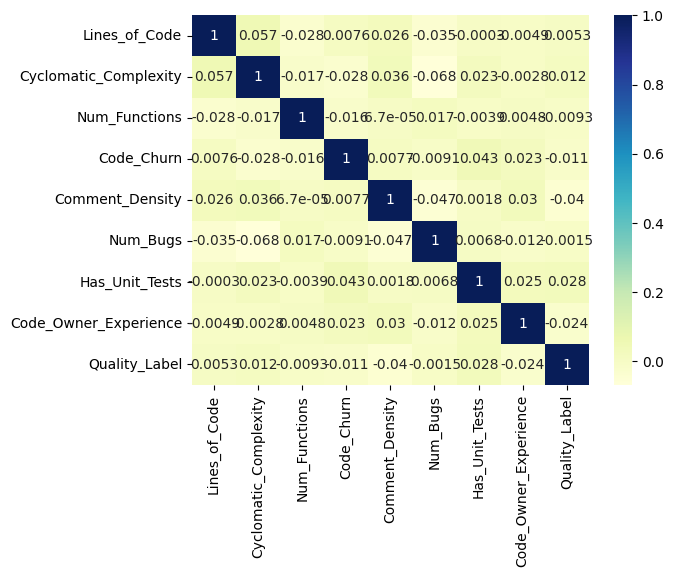

In [ ]:
sns.heatmap(dataset_corr, cmap = 'YlGnBu',annot=True)

In [ ]:
dataset.corr()

,Lines_of_Code,Cyclomatic_Complexity,Num_Functions,Code_Churn,Comment_Density,Num_Bugs,Has_Unit_Tests,Code_Owner_Experience,Quality_Label
Lines_of_Code,1.000000,0.057037,-0.027855,0.007572,0.026107,-0.034773,-0.000296,-0.004937,0.005278
Cyclomatic_Complexity,0.057037,1.000000,-0.017462,-0.027753,0.035944,-0.068117,0.023267,-0.002794,0.012301
Num_Functions,-0.027855,-0.017462,1.000000,-0.016454,0.000067,0.016783,-0.003942,0.004831,-0.009295
Code_Churn,0.007572,-0.027753,-0.016454,1.000000,0.007701,-0.009113,0.043109,0.023195,-0.010735
Comment_Density,0.026107,0.035944,0.000067,0.007701,1.000000,-0.047158,0.001790,0.030128,-0.040180
Num_Bugs,-0.034773,-0.068117,0.016783,-0.009113,-0.047158,1.000000,0.006795,-0.011806,-0.001512
Has_Unit_Tests,-0.000296,0.023267,-0.003942,0.043109,0.001790,0.006795,1.000000,0.025317,0.027898
Code_Owner_Experience,-0.004937,-0.002794,0.004831,0.023195,0.030128,-0.011806,0.025317,1.000000,-0.024281
Quality_Label,0.005278,0.012301,-0.009295,-0.010735,-0.040180,-0.001512,0.027898,-0.024281,1.000000


# **MODEL TRAINING**

**KNN**

In [ ]:
# import mglearn
# mglearn.plots.plot_knn_classification(n_neighbours=2)

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

knn = KNeighborsClassifier(n_neighbors=7)

# fit model
knn.fit(X_train_scaled, y_train)

# test
y_pred_knn = knn.predict(X_test_scaled)

# accurcay

print("Test set score of KNN: {:.2f}".format(np.mean(y_pred_knn == y_test)))
accuracy = accuracy_score(y_test, y_pred_knn)
print("Test set accuracy of KNN: {:.2f}".format(accuracy))


Test set score of KNN: 0.32
Test set accuracy of KNN: 0.32


In [ ]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1371 entries, 0 to 1599
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Lines_of_Code          1371 non-null   float64
 1   Cyclomatic_Complexity  1371 non-null   int64  
 2   Num_Functions          1371 non-null   int64  
 3   Code_Churn             1371 non-null   float64
 4   Comment_Density        1371 non-null   float64
 5   Num_Bugs               1371 non-null   int64  
 6   Has_Unit_Tests         1371 non-null   int64  
 7   Code_Owner_Experience  1371 non-null   int64  
 8   Quality_Label          1371 non-null   int64  
dtypes: float64(3), int64(6)
memory usage: 107.1 KB


**Naive Bayes**

In [ ]:
from sklearn.naive_bayes import GaussianNB

nb = GaussianNB()

# fit model
nb.fit(X_train_scaled, y_train)

# test
y_pred_nb = nb.predict(X_test_scaled)


# accuracy
# print("Test set accuracy of Naive Bayes: {:.2f}".format(nb.score(X_test_scaled, y_test)))

accuracy_nb = accuracy_score(y_test, y_pred_nb)
print("Test set accuracy of Naive Bayes: {:.2f}".format(accuracy_nb))



Test set accuracy of Naive Bayes: 0.32


**NN**

In [ ]:
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score

mlp = MLPClassifier(
    hidden_layer_sizes=(128, 64),
    activation='relu',
    solver='adam',
    alpha=0.0005,
    learning_rate='adaptive',
    max_iter=800,
    early_stopping=True,
    random_state=42
)

# fit model
mlp.fit(X_train_scaled, y_train)

# test
y_pred_nn = mlp.predict(X_test_scaled)

# accuracy
accuracy_nn = accuracy_score(y_test, y_pred_nn)
print("Test set accuracy of MLP: {:.2f}".format(accuracy_nn))


Test set accuracy of MLP: 0.34


In [ ]:
import numpy as np
import tensorflow as tf
from sklearn.metrics import accuracy_score


from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import SparseCategoricalCrossentropy

# convert data to correct types
X_train = np.asarray(X_train_scaled, dtype=np.float32)
X_test  = np.asarray(X_test_scaled, dtype=np.float32)

y_train = np.asarray(y_train, dtype=np.int32)
y_test  = np.asarray(y_test, dtype=np.int32)

# build model

model = Sequential([
    Input(shape=(X_train.shape[1],)),  # number of input features
    Dense(128, activation='relu'),      # Hidden layer
    Dense(3, activation='softmax')      # Output layer with 3 classes
])

# compile model
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss=SparseCategoricalCrossentropy(),
    metrics=['accuracy']
)

# train model
history = model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=128,
    validation_data=(X_test, y_test)
)

# test set
y_pred_nn = np.argmax(model.predict(X_test), axis=1)

# accuracy

accuracy_nn = accuracy_score(y_test, y_pred_nn)
print(f"Test Accuracy: {accuracy_nn:.2f}")


Epoch 1/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - accuracy: 0.3371 - loss: 1.1133 - val_accuracy: 0.3589 - val_loss: 1.1033
Epoch 2/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.3446 - loss: 1.1009 - val_accuracy: 0.3267 - val_loss: 1.1024
Epoch 3/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.3571 - loss: 1.0953 - val_accuracy: 0.3342 - val_loss: 1.1017
Epoch 4/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.3755 - loss: 1.0940 - val_accuracy: 0.3292 - val_loss: 1.1017
Epoch 5/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.3748 - loss: 1.0926 - val_accuracy: 0.3317 - val_loss: 1.1026
Epoch 6/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.3760 - loss: 1.0890 - val_accuracy: 0.3119 - val_loss: 1.1041
Epoch 7/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.3967 - loss: 1.0868 - val_accuracy: 0.3317 - val_loss: 1.1055
Epoch 8/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.3944 - loss: 1.0850 - val_accuracy: 0.3292 - val_loss: 1.1055


**K Means**

In [ ]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1371 entries, 0 to 1599
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Lines_of_Code          1371 non-null   float64
 1   Cyclomatic_Complexity  1371 non-null   int64  
 2   Num_Functions          1371 non-null   int64  
 3   Code_Churn             1371 non-null   float64
 4   Comment_Density        1371 non-null   float64
 5   Num_Bugs               1371 non-null   int64  
 6   Has_Unit_Tests         1371 non-null   int64  
 7   Code_Owner_Experience  1371 non-null   int64  
 8   Quality_Label          1371 non-null   int64  
dtypes: float64(3), int64(6)
memory usage: 107.1 KB


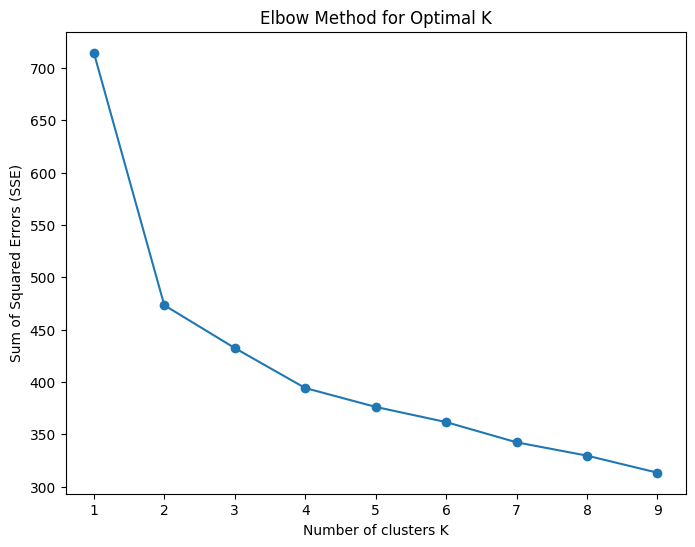

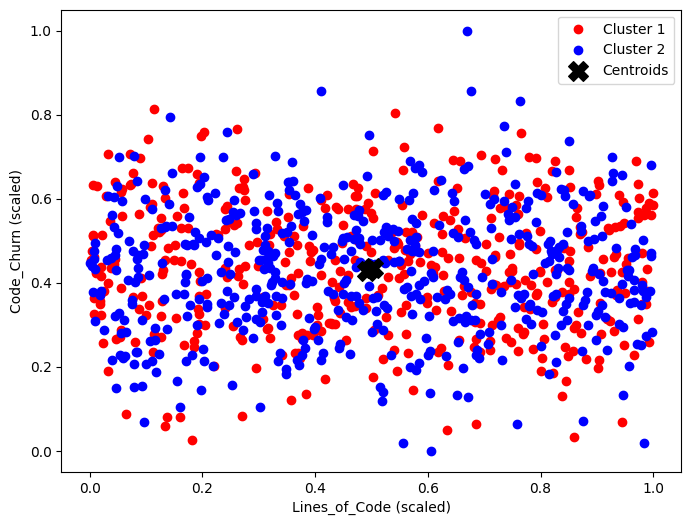

In [ ]:

import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

X_unsup_scaled = X_train_scaled.copy()


# Elbow Method to find optimal K

sse = []
for k in range(1, 10):
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(X_unsup_scaled)
    sse.append(km.inertia_)

plt.figure(figsize=(8, 6))
plt.plot(range(1, 10), sse, marker='o')
plt.xlabel("Number of clusters K")
plt.ylabel("Sum of Squared Errors (SSE)")
plt.title("Elbow Method for Optimal K")
plt.show()


kmeans = KMeans(n_clusters=2, random_state=42)
clusters = kmeans.fit_predict(X_unsup_scaled)


plt.figure(figsize=(8, 6))
colors = ['red', 'blue']
feature_x_idx = 0  # Lines_of_Code
feature_y_idx = 3  # Code_Churn (example)

for i in range(2):
    plt.scatter(
        X_unsup_scaled[clusters == i, feature_x_idx],
        X_unsup_scaled[clusters == i, feature_y_idx],
        color=colors[i],
        label=f'Cluster {i+1}'
    )

# Plot centroids
centers = kmeans.cluster_centers_
plt.scatter(
    centers[:, feature_x_idx],
    centers[:, feature_y_idx],
    s=200,
    c='black',
    marker='X',
    label='Centroids'
)

plt.xlabel('Lines_of_Code (scaled)')
plt.ylabel('Code_Churn (scaled)')
plt.legend()
plt.show()


# **MODEL EVALUATION**


In [ ]:
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix

# -----------------------------
# Models and their predictions
# -----------------------------
models = {
    "KNN": y_pred_knn,
    "Naive Bayes": y_pred_nb,
    "MLP (Neural Network)": y_pred_nn
}

# -----------------------------
# Evaluate each model
# -----------------------------
for name, pred in models.items():
    print(f"Model: {name}")
    print("Accuracy:", accuracy_score(y_test, pred))
    print("F1 Score:", f1_score(y_test, pred, average='weighted'))
    # print("Confusion Matrix:\n", confusion_matrix(y_test, pred))
    # print("-"*40)


Model: KNN
Accuracy: 0.31683168316831684
F1 Score: 0.3136925874554876
Model: Naive Bayes
Accuracy: 0.3193069306930693
F1 Score: 0.31155499342029297
Model: MLP (Neural Network)
Accuracy: 0.30198019801980197
F1 Score: 0.29729998138170466


KNN - Mean AUC: 0.50
Naive Bayes - Mean AUC: 0.46
MLP (Neural Network) - Mean AUC: 0.53


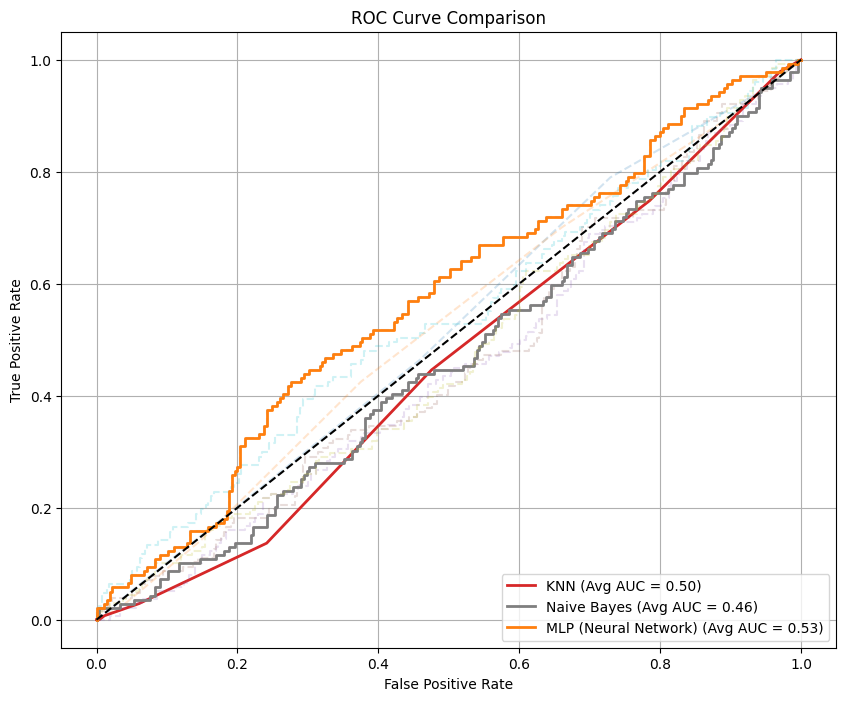

In [ ]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
import numpy as np

# -----------------------------
# Models (trained models only)
# -----------------------------
models = {
    "KNN": knn,
    "Naive Bayes": nb,
    "MLP (Neural Network)": mlp
}

# -----------------------------
# Prepare multiclass labels
# -----------------------------
classes = np.unique(y_test)
y_test_bin = label_binarize(y_test, classes=classes)

plt.figure(figsize=(10, 8))

# -----------------------------
# Plot ROC curve and print AUC
# -----------------------------
for name, model in models.items():

    # Get predicted probabilities
    if name == "Naive Bayes":
        y_probs = model.predict_proba(X_test)          # NB uses unscaled features
    else:
        y_probs = model.predict_proba(X_test_scaled)   # KNN/MLP use scaled features

    aucs = []

    # Per-class ROC curves
    for i in range(len(classes)):
        fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_probs[:, i])
        roc_auc = auc(fpr, tpr)
        aucs.append(roc_auc)
        plt.plot(fpr, tpr, linestyle='--', alpha=0.2)  # faint per-class lines

    # Mean AUC for the model
    mean_auc = np.mean(aucs)
    print(f"{name} - Mean AUC: {mean_auc:.2f}")   # ✅ print the AUC value
    plt.plot(fpr, tpr, linewidth=2, label=f"{name} (Avg AUC = {mean_auc:.2f})")

# Diagonal reference line
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend(loc="lower right")
plt.grid()
plt.show()


**Multiclass** **Confusion** **Matrix**



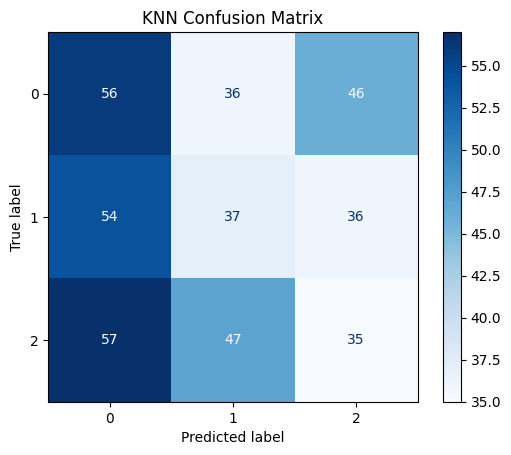

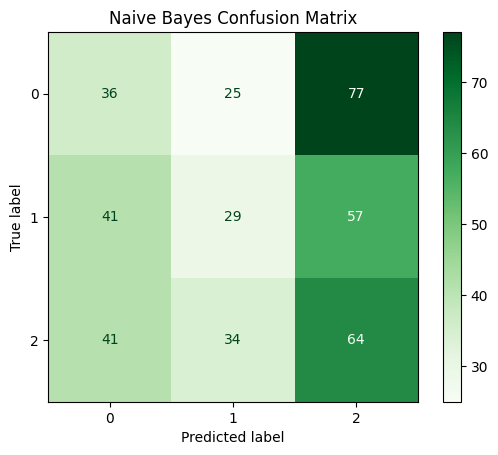

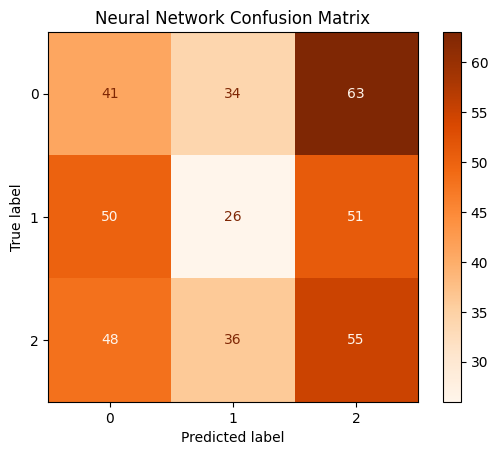

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np

# -----------------------------
# List of models and predictions
# -----------------------------
model_preds = {
    "KNN": y_pred_knn,
    "Naive Bayes": y_pred_nb,
    "Neural Network": y_pred_nn
}

# Automatically get class labels
labels = np.unique(y_test)

# -----------------------------
# Plot confusion matrices
# -----------------------------
colors = {
    "KNN": "Blues",
    "Naive Bayes": "Greens",
    "Neural Network": "Oranges"
}

for name, pred in model_preds.items():
    cm = confusion_matrix(y_test, pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=labels)
    disp.plot(cmap=colors[name])
    plt.title(f"{name} Confusion Matrix")
    plt.show()

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pandas as pd

# Create comparison table
performance_df = pd.DataFrame({
    "Model": ["KNN", "Naive Bayes", "Neural Network"],
    "Accuracy": [
        accuracy_score(y_test, y_pred_knn),
        accuracy_score(y_test, y_pred_nb),
        accuracy_score(y_test, y_pred_nn)
    ],
    "Precision": [
        precision_score(y_test, y_pred_knn, average='weighted'),
        precision_score(y_test, y_pred_nb, average='weighted'),
        precision_score(y_test, y_pred_nn, average='weighted')
    ],
    "Recall": [
        recall_score(y_test, y_pred_knn, average='weighted'),
        recall_score(y_test, y_pred_nb, average='weighted'),
        recall_score(y_test, y_pred_nn, average='weighted')
    ],
    "F1-Score": [
        f1_score(y_test, y_pred_knn, average='weighted'),
        f1_score(y_test, y_pred_nb, average='weighted'),
        f1_score(y_test, y_pred_nn, average='weighted')
    ]
})

performance_df


,Model,Accuracy,Precision,Recall,F1-Score
0,KNN,0.316832,0.314394,0.316832,0.313693
1,Naive Bayes,0.319307,0.319018,0.319307,0.311555
2,Neural Network,0.301980,0.297865,0.301980,0.297300


In [ ]:
from sklearn.metrics import classification_report
import numpy as np

model_preds = {
    "KNN": y_pred_knn,
    "Naive Bayes": y_pred_nb,
    "Neural Network": y_pred_nn
}

class_labels = np.unique(y_test).astype(str)

for name, pred in model_preds.items():
    print(f" {name} Classification Report ")
    print(classification_report(y_test, pred, target_names=class_labels))

 KNN Classification Report 
              precision    recall  f1-score   support

           0       0.34      0.41      0.37       138
           1       0.31      0.29      0.30       127
           2       0.30      0.25      0.27       139

    accuracy                           0.32       404
   macro avg       0.31      0.32      0.31       404
weighted avg       0.31      0.32      0.31       404

 Naive Bayes Classification Report 
              precision    recall  f1-score   support

           0       0.31      0.26      0.28       138
           1       0.33      0.23      0.27       127
           2       0.32      0.46      0.38       139

    accuracy                           0.32       404
   macro avg       0.32      0.32      0.31       404
weighted avg       0.32      0.32      0.31       404

 Neural Network Classification Report 
              precision    recall  f1-score   support

           0       0.29      0.30      0.30       138
           1       0.27   

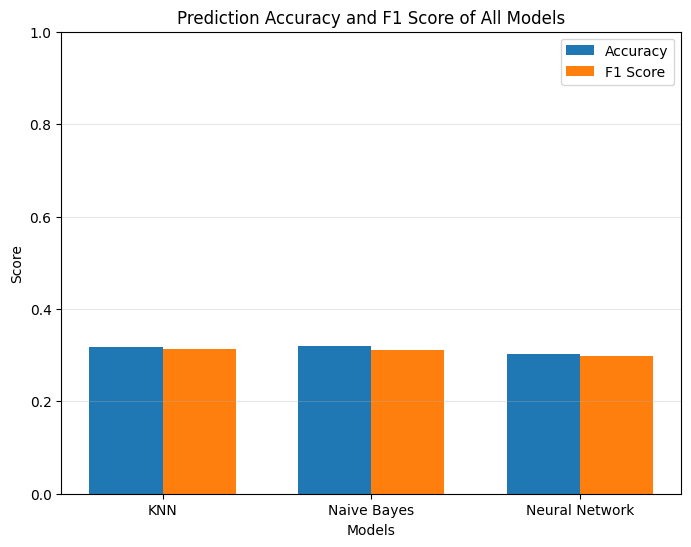

In [ ]:
from sklearn.metrics import accuracy_score, f1_score
import matplotlib.pyplot as plt
import numpy as np

models = ['KNN', 'Naive Bayes', 'Neural Network']

# accuracy

accuracy_scores = [
    accuracy_score(y_test, y_pred_knn),
    accuracy_score(y_test, y_pred_nb),
    accuracy_score(y_test, y_pred_nn)   # fixed variable name
]

# F1 scores (weighted for multiclass)

f1_scores = [
    f1_score(y_test, y_pred_knn, average='weighted'),
    f1_score(y_test, y_pred_nb, average='weighted'),
    f1_score(y_test, y_pred_nn, average='weighted')
]
# bar chart

x = np.arange(len(models))
width = 0.35

plt.figure(figsize=(8, 6))
plt.bar(x - width/2, accuracy_scores, width, label='Accuracy')
plt.bar(x + width/2, f1_scores, width, label='F1 Score')

plt.xlabel('Models')
plt.ylabel('Score')
plt.title('Prediction Accuracy and F1 Score of All Models')
plt.xticks(x, models)
plt.ylim(0, 1)
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.show()
